# Analysis of Features Shipped This Year
This notebook analyzes the git repository to track the number of new features shipped since the beginning of the current year.

In [6]:
import subprocess
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import os

# Get the current year
current_year = datetime.datetime.now().year
print(f"Analyzing features shipped since: {current_year}-01-01")

Analyzing features shipped since: 2026-01-01


In [7]:
# Fetch git log since the beginning of the year from the correct repo
repo_path = os.path.expanduser("~/Github_nicolasakf/Orion")

# We use --no-pager to avoid hanging, and format as "ISO-Date|Commit Message"
cmd = [
    "git", "-C", repo_path, "--no-pager", "log", 
    f"--since={current_year}-01-01", 
    "--format=%aI|%s"
]

try:
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)
    git_log_output = result.stdout.strip()
    print(f"Successfully fetched git history from {repo_path}.")
except subprocess.CalledProcessError as e:
    print(f"Error fetching git history: {e}")
    git_log_output = ""
except FileNotFoundError:
    print(f"Directory not found: {repo_path}")
    git_log_output = ""

Successfully fetched git history from /Users/nicolasfonteyne/Github_nicolasakf/Orion.


In [8]:
# Parse the git log into a DataFrame
commits = []
if git_log_output:
    for line in git_log_output.split('\n'):
        if '|' in line:
            date_str, msg = line.split('|', 1)
            commits.append({'date': pd.to_datetime(date_str), 'message': msg})

df = pd.DataFrame(commits)
if not df.empty:
    df['date'] = pd.to_datetime(df['date'], utc=True)
    df.set_index('date', inplace=True)
    print(f"Total commits found this year: {len(df)}")
else:
    print("No commits found since the beginning of the year.")

Total commits found this year: 332


In [9]:
# Filter for feature commits
# We'll look for conventional commit patterns like "feat:", "feat(", or the word "feature"
if not df.empty:
    feature_mask = df['message'].str.contains(r'^(?:feat|feature)[:\(]|\bfeature\b', case=False, na=False)
    features_df = df[feature_mask].copy()
    print(f"Total features shipped: {len(features_df)}")
    display(features_df.head())
else:
    features_df = pd.DataFrame()
    print("No features shipped yet this year.")

Total features shipped: 136


,message
date,
2026-04-17 22:24:40+00:00,feat(notebook): add toolbar toggle to hide all...
2026-04-17 22:24:39+00:00,feat(account): add self-service account deletion
2026-04-17 21:29:54+00:00,feat(sidebar): variables panel kernel link and...
2026-04-17 21:29:53+00:00,feat(kernel): notify session listeners on acti...
2026-04-16 23:23:23+00:00,feat(sidebar): update await_command icon to Ho...


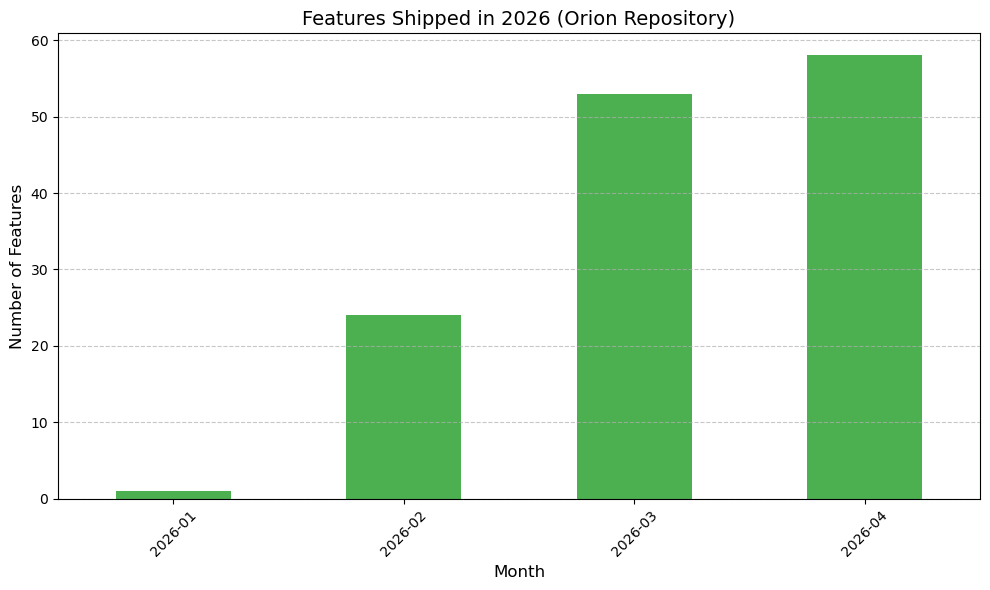

In [10]:
# Visualize features shipped over time
if not features_df.empty:
    # Resample by month end (ME)
    monthly_features = features_df.resample('ME').size()
    
    # Optional: ensure we only plot up to the current month to avoid plotting a trailing empty bar for future months if applicable
    plt.figure(figsize=(10, 6))
    monthly_features.plot(kind='bar', color='#4CAF50')
    
    # Format the x-axis to show Year-Month nicely
    plt.gca().set_xticklabels([x.strftime('%Y-%m') for x in monthly_features.index])
    
    plt.title(f'Features Shipped in {current_year} (Orion Repository)', fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of Features', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
elif not df.empty:
    print("Commits exist, but no feature-specific commits were found to plot.")
else:
    print("Not enough data to create a plot.")